In [56]:
from Bio import SeqIO
import sys
import torch
from torch.nn.utils.rnn import pad_sequence
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

In [ ]:
for record in SeqIO.parse("proteins.fasta", "fasta"):
    print(record.id)
    print(record.seq)
    print(len(record.seq))
    print()

In [4]:
sequences = []

for record in SeqIO.parse("proteins.fasta", "fasta"):
    sequences.append(str(record.seq))

print(len(sequences))
print(sequences[0])

126
MSEYQPSLFALNPMGFSPLDGSKSTNENVSASTSTAKPMVGQLIFDKFIKTEEDPIIKQDTPSNLDFDFALPQTATAPDAKTVLPIPELDDAVVESFFSSSTDSTPMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADKAIESTEEVSLVPSNLEVSTTSFLPTPVLEDAKLTQTRKVKKPNSVVKKSHHVGKDDESRLDHLGVVAYNRKQRSIPLSPIVPESSDPAALKRARNTEAARRSRARKLQRMKQLEDKVEELLSKNYHLENEVARLKKLVGER


In [5]:
data = []

for record in SeqIO.parse("proteins.fasta", "fasta"):
    data.append({
        "id":record.id,
        "sequence":str(record.seq)
    })

print(data[0])

{'id': 'sp|P03069|GCN4_YEAST', 'sequence': 'MSEYQPSLFALNPMGFSPLDGSKSTNENVSASTSTAKPMVGQLIFDKFIKTEEDPIIKQDTPSNLDFDFALPQTATAPDAKTVLPIPELDDAVVESFFSSSTDSTPMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADKAIESTEEVSLVPSNLEVSTTSFLPTPVLEDAKLTQTRKVKKPNSVVKKSHHVGKDDESRLDHLGVVAYNRKQRSIPLSPIVPESSDPAALKRARNTEAARRSRARKLQRMKQLEDKVEELLSKNYHLENEVARLKKLVGER'}


In [7]:
df = pd.DataFrame(data)
df.head()

,id,sequence
0,sp|P03069|GCN4_YEAST,MSEYQPSLFALNPMGFSPLDGSKSTNENVSASTSTAKPMVGQLIFD...
1,sp|P05317|RLA0_YEAST,MGGIREKKAEYFAKLREYLEEYKSLFVVGVDNVSSQQMHEVRKELR...
2,sp|P05737|RL7A_YEAST,MAAEKILTPESQLKKSKAQQKTAEQVAAERAARKAANKEKRAIILE...
3,sp|P05748|RL15A_YEAST,MGAYKYLEELQRKKQSDVLRFLQRVRVWEYRQKNVIHRAARPTRPD...
4,sp|P05750|RS3_YEAST,MVALISKKRKLVADGVFYAELNEFFTRELAEEGYSGVEVRVTPTKT...


In [8]:
df["length"] = df["sequence"].apply(len)
df["length"].describe()

count    126.000000
mean     292.801587
std       57.776676
min      203.000000
25%      246.250000
50%      288.000000
75%      343.250000
max      396.000000
Name: length, dtype: float64

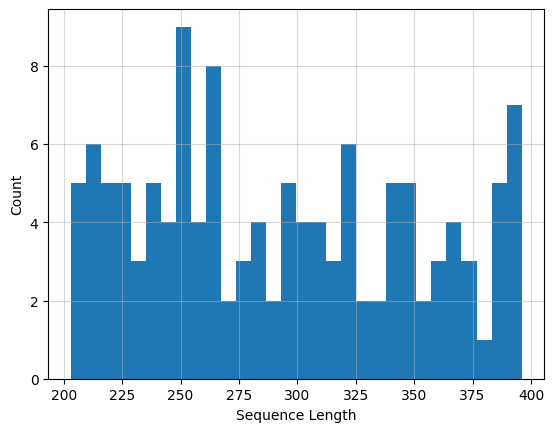

In [21]:
plt.hist(df["length"], bins=30)
plt.xlabel("Sequence Length")
plt.ylabel("Count")
plt.grid(alpha=0.5)
plt.show()

In [22]:
print(df.sequence[0])

MSEYQPSLFALNPMGFSPLDGSKSTNENVSASTSTAKPMVGQLIFDKFIKTEEDPIIKQDTPSNLDFDFALPQTATAPDAKTVLPIPELDDAVVESFFSSSTDSTPMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADKAIESTEEVSLVPSNLEVSTTSFLPTPVLEDAKLTQTRKVKKPNSVVKKSHHVGKDDESRLDHLGVVAYNRKQRSIPLSPIVPESSDPAALKRARNTEAARRSRARKLQRMKQLEDKVEELLSKNYHLENEVARLKKLVGER


In [44]:
amino_acids = "ACDEFGHIKLMNPQRSTVWY"

aa_to_int = {aa:i for i,aa in enumerate(amino_acids)}

def encode_sequence(seq):
    return [aa_to_int.get(a, 0) for a in seq]

In [45]:
encode_sequence("MSTNTL")

[10, 15, 16, 11, 16, 9]

In [46]:
df["encoded"] = df["sequence"].apply(encode_sequence)

In [47]:
encoded_tensors = [torch.tensor(seq) for seq in df["encoded"]]

X = pad_sequence(encoded_tensors, batch_first=True)

In [48]:
X.shape

torch.Size([126, 396])

In [49]:
def label_protein(pid):

    if "RPL" in pid or "RPS" in pid:
        return 1
    else:
        return 0

df["label"] = df["id"].apply(label_protein)

y = torch.tensor(df["label"].values)

In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [59]:
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

In [60]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

In [50]:
class ProteinNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.embedding = nn.Embedding(20, 64)

        self.conv = nn.Conv1d(64, 128, 5)

        self.pool = nn.AdaptiveMaxPool1d(1)

        self.fc = nn.Linear(128, 2)

    def forward(self, x):

        x = self.embedding(x)

        x = x.permute(0,2,1)

        x = torch.relu(self.conv(x))

        x = self.pool(x).squeeze()

        return self.fc(x)

In [51]:
model = ProteinNet()

In [52]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [61]:
for epoch in range(20):

    model.train()

    total_loss = 0

    for batch_X, batch_y in train_loader:

        optimizer.zero_grad()

        outputs = model(batch_X)

        loss = criterion(outputs, batch_y)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print("epoch", epoch, "loss", total_loss)

epoch 0 loss 0.0002079347523249453
epoch 1 loss 0.00011374697987776017
epoch 2 loss 8.349065319634974e-05
epoch 3 loss 7.296310650417581e-05
epoch 4 loss 6.663764133918448e-05
epoch 5 loss 6.20630316916504e-05
epoch 6 loss 6.0774093071813695e-05
epoch 7 loss 6.152659125291393e-05
epoch 8 loss 6.055057565390598e-05
epoch 9 loss 5.8352676660433644e-05
epoch 10 loss 5.9090275499329437e-05
epoch 11 loss 6.061762951503624e-05
epoch 12 loss 5.768212940893136e-05
epoch 13 loss 5.724254788219696e-05
epoch 14 loss 5.743626024923287e-05
epoch 15 loss 5.881459765078034e-05
epoch 16 loss 5.8918915783578996e-05
epoch 17 loss 5.821856302645756e-05
epoch 18 loss 5.701158124793437e-05
epoch 19 loss 5.6788067468005465e-05


In [66]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for batch_X, batch_y in test_loader:

        outputs = model(batch_X)

        predicted = torch.argmax(outputs, dim=1)

        correct += (predicted == batch_y).sum().item()

        total += batch_y.size(0)

print("Accuracy:", correct / total)

Accuracy: 1.0


In [78]:
import random

random_seq = X_test[0].unsqueeze(0)

with torch.no_grad():
    pred = model(random_seq)

print(torch.softmax(pred, dim=0))

tensor([9.9999e-01, 6.9305e-06])


In [79]:
torch.save(model.state_dict(), "protein_model.pth")

In [84]:
def predict(sequence):

    encoded = [aa_to_int[a] for a in sequence]

    x = torch.tensor(encoded).unsqueeze(0)

    with torch.no_grad():
        pred = model(x)

    prob = torch.softmax(pred, dim=0)

    return prob

In [85]:
predict("MSTNTLQKLA")

tensor([0.9987, 0.0013])